<a href="https://colab.research.google.com/github/vishnuvs0712-maker/Machine-Learning-codes/blob/main/1000_Companies_Linear_Regression_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [20]:
dataset = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Dataset/1000_Companies.csv')

In [21]:
print(dataset.head())

   R&D Spend  Administration  Marketing Spend       State     Profit
0  165349.20       136897.80        471784.10    New York  192261.83
1  162597.70       151377.59        443898.53  California  191792.06
2  153441.51       101145.55        407934.54     Florida  191050.39
3  144372.41       118671.85        383199.62    New York  182901.99
4  142107.34        91391.77        366168.42     Florida  166187.94


In [22]:
# Separate features and target
X = dataset.iloc[:, :-1]
y = dataset.iloc[:, -1]

In [23]:
print(X.head())
print(y.head())

   R&D Spend  Administration  Marketing Spend       State
0  165349.20       136897.80        471784.10    New York
1  162597.70       151377.59        443898.53  California
2  153441.51       101145.55        407934.54     Florida
3  144372.41       118671.85        383199.62    New York
4  142107.34        91391.77        366168.42     Florida
0    192261.83
1    191792.06
2    191050.39
3    182901.99
4    166187.94
Name: Profit, dtype: float64


In [24]:
ct = ColumnTransformer(
    transformers=[('encoder', OneHotEncoder(drop='first'), [3])],
    remainder='passthrough'
)


In [25]:
X = ct.fit_transform(X)

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [27]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [28]:
y_pred = model.predict(X_test)


In [29]:
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

In [30]:
print(results.head(10))

           Actual      Predicted
521  124269.48590  124953.799647
737  111257.77400  111734.495032
740   91370.72519   90901.263642
660  126846.88300  127455.942922
411  161008.28630  161129.991242
678   91441.63138   90972.771740
626  154051.79170  154891.799215
513  138588.26360  139296.998315
859   87654.55773   88028.040313
136   91139.21223   90667.785229


In [31]:
print("\nModel Performance")
print("-----------------")
print("R² Score :", r2_score(y_test, y_pred))
print("MAE      :", mean_absolute_error(y_test, y_pred))
print("MSE      :", mean_squared_error(y_test, y_pred))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, y_pred)))


Model Performance
-----------------
R² Score : 0.9825277846008168
MAE      : 1404.4378483074734
MSE      : 30775142.85678003
RMSE     : 5547.5348450262145



Intercept:
-82439.15560710836

Coefficients:
[-8.74491486e+02 -9.71337988e+01  5.33045605e-01  1.13893831e+00
  8.30755037e-02]


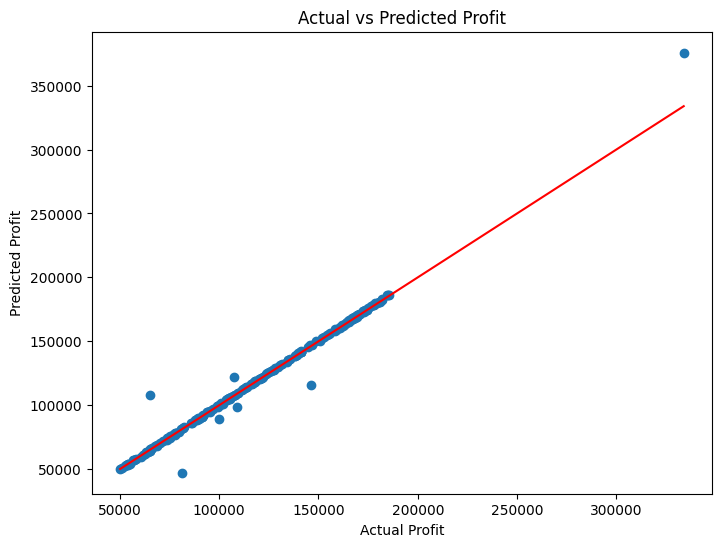

In [32]:
print("\nIntercept:")
print(model.intercept_)

print("\nCoefficients:")
print(model.coef_)

# Scatter Plot
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Actual vs Predicted Profit")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.show()